The **SMS Spam Classification** dataset contains **5,574 English SMS messages** collected for spam detection research and is designed for developing machine learning models to classify text messages as either legitimate or spam. It consists of **two columns**: **v2**, which contains the raw SMS message text, and **v1**, the target variable indicating whether the message is **ham (legitimate)** or **spam**. Before training the model, the SMS messages are converted into numerical feature vectors using the **Bag of Words (BoW)** technique, allowing the text data to be processed by a machine learning algorithm. In this project, a **single-neuron binary classification model** with a **sigmoid activation function** is used to predict the probability that a message is spam. The dataset was obtained from the Kaggle platform and is available at: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset.

### import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### load dataset

In [2]:
sms = pd.read_csv("spam.csv", encoding="latin-1")
sms = sms[["v1", "v2"]]

sms.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### clean sms text
1. convert to lower case.
2. Remove punctuation.
3. Remove extra spaces.
4. Remove standalone numbers.

In [3]:
sms["v2"] = sms["v2"].str.lower()
sms["v2"] = sms["v2"].str.replace(r"[^\w\s]", "", regex=True)
sms["v2"] = sms["v2"].str.replace(r"\s+", " ", regex=True).str.strip()
sms["v2"] = sms["v2"].str.replace(r"\b\d+\b", "", regex=True)
sms["tokens"] = sms["v2"].str.split()

print(sms["tokens"].head())

0    [go, until, jurong, point, crazy, available, o...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, in, a, wkly, comp, to, win, fa, ...
3    [u, dun, say, so, early, hor, u, c, already, t...
4    [nah, i, dont, think, he, goes, to, usf, he, l...
Name: tokens, dtype: object


### check if there's NaN in dataset

In [4]:
print(sms["v2"].isna().sum())

0


### build bag of wards

In [5]:
vocab = sorted(set(
    word
    for tokens in sms["tokens"]
    for word in tokens
    if word[0].isalpha()
))

print(len(vocab), vocab[:50])

8663 ['a', 'a21', 'a30', 'aa', 'aah', 'aaniye', 'aaooooright', 'aathilove', 'aathiwhere', 'ab', 'abbey', 'abdomen', 'abeg', 'abel', 'aberdeen', 'abi', 'ability', 'abiola', 'abj', 'able', 'abnormally', 'about', 'aboutas', 'above', 'abroad', 'absence', 'absolutely', 'abstract', 'abt', 'abta', 'aburo', 'abuse', 'abusers', 'ac', 'academic', 'acc', 'accent', 'accenture', 'accept', 'access', 'accessible', 'accidant', 'accident', 'accidentally', 'accommodation', 'accommodationvouchers', 'accomodate', 'accomodations', 'accordin', 'accordingly']


### word to index

In [22]:
word_to_index = {
  word: i
  for i, word in enumerate(vocab)
}

print(len(word_to_index))

8663


### build X array of feature

In [21]:
# +1 for the bias term prepended as the first column
X = np.zeros((len(sms["tokens"]), len(vocab) + 1), dtype=int)
X[:, 0] = 1  # bias column

print(X.shape)

(5572, 8664)


### fill X array

In [8]:
for i, message in enumerate(sms["tokens"]):

  for word in message:

    if word in word_to_index:

      j = word_to_index[word] + 1  # +1 to skip bias column at index 0

      X[i, j] += 1

print(X)  # shifted by 1 due to bias

[[1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]]


### encode labels

In [9]:
label = sms["v1"]
label_names = sorted(set(label))
label_names_to_int = {name: i for i, name in enumerate(label_names)}
y = np.array([label_names_to_int[l] for l in label])

# ham -> 0, spam -> 1
print(label_names_to_int)
print(y[:10])
n = len(y)

{'ham': 0, 'spam': 1}
[0 0 1 0 0 1 0 0 1 1]


What happens until the X feature array is ready ???

1. Load dataset Read the CSV file. Each row is one SMS. You keep only two columns: v1 (the label: ham or spam) and v2 (the raw message text).

2. Clean the text For every message you:

Make everything lowercase ("FREE PRIZE" → "free prize")
Remove punctuation ("hello!" → "hello")
Collapse extra spaces
Remove standalone numbers ("win 500 now" → "win now")
Split into a list of words → ["win", "now"] — these are called tokens
3. Check for NaN Just a sanity check — make sure no message is empty/missing after cleaning.

4. Build vocabulary Collect every unique word that appears across all 5,574 messages, keep only words that start with a letter, and sort them A→Z. This gives you the master list of known words (~8,600 words).

5. Word to index Give every word in the vocab a number: "a" → 0, "able" → 19, "call" → 1030, etc. Just a lookup table for speed.

6. Build X (empty matrix) Create a table of zeros with shape 5574 rows × 8664 columns (vocab size + 1 for bias). Each row = one message, each column = one word slot. Column 0 is all 1s (the bias).

7. Fill X Go through every message, and for each word in it, find its column number and add 1 to that cell. So if message 3 contains the word "free" twice, X[3, index_of_free] = 2. Now every message is represented as a row of word counts.

8. Encode labels The label column has text: "ham" and "spam". The model can't work with text, so you convert:

"ham" → 0
"spam" → 1
Now y is a simple array of 0s and 1s that the model can learn from.

### train and test split

In [10]:
def train_test_split(X, y, test_frac=0.25, seed=0):
  r = np.random.default_rng(seed)
  idx = r.permutation(len(X))
  n_test = int(len(X) * test_frac)
  test, train = idx[:n_test], idx[n_test:]
  return X[train], y[train], X[test], y[test]

X_train, y_train, X_test, y_test = train_test_split(X, y)

### Sigmoid

In [11]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

### Predict

In [12]:
# w has one weight per vocab word + 1 for the bias term
w = np.zeros(X.shape[-1])
lr = 0.1

def predict(X, w):
  z = X @ w
  return sigmoid(z)

### Loss

In [13]:
def loss(X, y, w):
  e = predict(X, w) - y
  return np.mean(e**2)

### Gradient

In [14]:
def gradient(X, y, w):
  e = predict(X, w) - y
  return (2/n) * (X.T @ e)

### training loop

### Early Stopping Using Loss Tolerance

To avoid unnecessary training iterations, an **early stopping** strategy is implemented based on a **loss tolerance ()**. After each epoch, the current loss is compared with the loss from the previous epoch. If the absolute difference between the two losses is smaller than a predefined tolerance value (e.g., ), the optimization process is considered to have converged, and training is stopped early. This approach reduces computation time while preventing the model from performing additional epochs that produce negligible improvements in the loss.

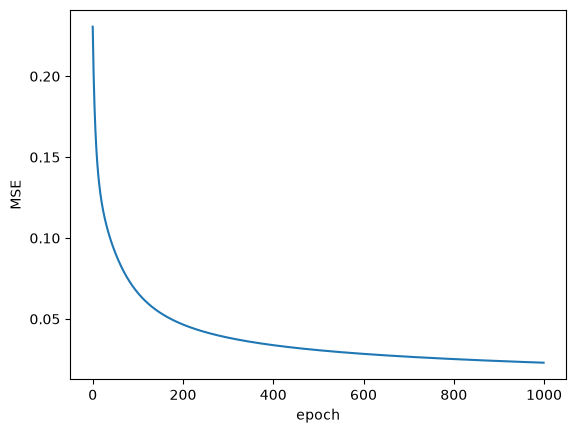

0.02297240789206157


In [15]:
def train_loop(X, y, w, epochs=10_000, tol=1e-6, plot=True):
  hist = []
  prev_loss = float("inf")
  for epoch in range(epochs):
    g = gradient(X, y, w)
    w = w - lr * g
    l = loss(X, y, w)
    hist.append(l)
    if abs(prev_loss - l) < tol:
      print(f"Stopped at epoch {epoch}")
      break
    prev_loss = l

  if plot:
    plt.plot(hist)
    plt.xlabel("epoch"); plt.ylabel("MSE")
    plt.show()
  return w, l

w, l = train_loop(X_train, y_train, w)
print(l)

### save model weights

In [16]:
import os

MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

# save weights vector
np.save(os.path.join(MODEL_DIR, "weights.npy"), w)

# save vocab so weights can be mapped back to words later
np.save(os.path.join(MODEL_DIR, "vocab.npy"), np.array(vocab))

print(f"Weights saved to {MODEL_DIR}/weights.npy")
print(f"Vocab saved  to  {MODEL_DIR}/vocab.npy")

Weights saved to model/weights.npy
Vocab saved  to  model/vocab.npy


When a new message comes in at prediction time, you need to convert it into a feature vector of the exact same size and order as the training data. The weights w[500] for example learned something about a specific word — if you don't know which word that column corresponds to, you can't build the right vector.

Concrete example:

During training, "free" ended up at column index 2540. So w[2540] learned that "free" is a strong spam signal.

At prediction time, you load a new message "free prize". To build the feature vector you need to know: which column does "free" go into? — you look it up in vocab.npy → column 2540. Without the vocab file you'd have no idea, and you might put "free" in the wrong column, which means the wrong weight gets applied and the prediction is garbage.

In short:

weights.npy — the learned numbers (what the model knows)
vocab.npy — the mapping that lets you speak the same language as the model (word → column index)

### Accuracy

In [17]:
def accuracy(pred, true):
  return np.mean(pred == true)

### test with test data

In [20]:
y_hat = predict(X_test, w)
print(f"Accuracy = {accuracy((y_hat >= 0.5).astype(int), y_test)*100:.2f}%")

Accuracy = 97.13%
[-2.90808501  0.47496554  0.00546507 ...  0.00715669  0.
 -0.02093297]


### test with new data from real world

In [19]:
def predict_message(message, word_to_index, w):
  import re
  # apply same cleaning as training data
  message = message.lower()
  message = re.sub(r"[^\w\s]", "", message)
  message = re.sub(r"\s+", " ", message).strip()
  message = re.sub(r"\b\d+\b", "", message)
  tokens = message.split()

  # build feature vector with bias at index 0
  x = np.zeros(len(word_to_index) + 1)
  x[0] = 1.0  # bias
  for word in tokens:
    if word in word_to_index:
      x[word_to_index[word] + 1] += 1

  prob = sigmoid(x @ w)
  label = "spam" if prob >= 0.5 else "ham"
  return label, prob


test_messages = [
  "Congratulations! You have won a free ticket. Call now to claim your prize!",
  "Hey, are we still meeting for lunch tomorrow?",
  "WINNER!! As a valued network customer you have been selected to receive a 900 prize reward!",
  "Can you pick up some milk on your way home?",
]

for msg in test_messages:
  label, prob = predict_message(msg, word_to_index, w)
  print(f"[{label.upper()}] ({prob:.2%}) — {msg[:60]}")

[SPAM] (98.05%) — Congratulations! You have won a free ticket. Call now to cla
[HAM] (3.52%) — Hey, are we still meeting for lunch tomorrow?
[SPAM] (62.70%) — WINNER!! As a valued network customer you have been selected
[HAM] (5.28%) — Can you pick up some milk on your way home?
